# Table of Contents

1. [Data Loading and Validation](#1-data-loading-and-validation)  
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)  
3. [Data Cleaning and Feature Engineering](#3-data-cleaning-and-feature-engineering)  
4. [Univariate Analysis - Target-variable Diagnostics](#4-univariate-analysis---target-variable-diagnostics)  
   - [Target Variable Analysis - Key Findings](#target-variable-analysis---key-findings)  
5. [Multivariate Analysis - Temporal Trends Analysis](#5-multivariate-analysis---temporal-trends-analysis)  
   - [Temporal Trends - Key Findings](#temporal-trends---key-findings)  
6. [Categorical Predictors - Hypothesis Testing](#6-categorical-predictors---hypothesis-testing)  
   - [Season Effect Findings](#season-effect-findings)  
   - [Weather Effect Findings](#weather-effect-findings)  
   - [Workingday & Holiday Effect Findings](#workingday--holiday-effect-findings)  
7. [Continuous Predictors - Correlation, Leakage, and Multicollinearity](#7-continuous-predictors---correlation-leakage-and-multicollinearity)  
   - [Continuous Predictors - Key Findings](#continuous-predictors---key-findings)  
8. [Predictive Modeling](#8-predictive-modeling)  
   - [Predictive Modeling Findings](#predictive-modeling-findings)  
9. [Insights and Business Recommendations](#9-insights-and-business-recommendations)  
   - [Variables Significant in Predicting Demand](#variables-which-are-significant-in-predicting-demand)  
   - [How Well These Variables Explain Demand](#how-well-do-these-variables-explain-demand)  
   - [Key Business Insights](#key-business-insights)  
   - [Recommendations](#recommendations)

## 1. Data Loading and Validation
---

Assumes file `bike_sharing.csv` is available in the home directory

In [1]:
# Prerequisites
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import skew, kurtosis, normaltest, kruskal, mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams["figure.figsize"] = (12, 6)
RANDOM_STATE = 42

In [2]:
# Load and Validate data
df_raw = pd.read_csv('bike_sharing.csv')

required_columns = [
    "datetime", "season", "holiday", "workingday", "weather", "temp", "atemp",
    "humidity", "windspeed", "casual", "registered", "count",
]
missing_required = sorted(set(required_columns) - set(df_raw.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df_raw["datetime"] = pd.to_datetime(df_raw["datetime"], errors="coerce")
if df_raw["datetime"].isna().any():
    raise ValueError("Some datetime values could not be parsed.")

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Time period: {df_raw['datetime'].min()} to {df_raw['datetime'].max()}")
display(df_raw.head())

Shape: 10,886 rows × 12 columns
Time period: 2011-01-01 00:00:00 to 2012-12-19 23:00:00


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.840,14.395,81,0.000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.020,13.635,80,0.000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.020,13.635,80,0.000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.840,14.395,75,0.000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.840,14.395,75,0.000,0,1,1


In [3]:
# Data-quality audit
quality_summary = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(3),
    "unique_values": df_raw.nunique(),
})

print(f"Duplicate rows: {df_raw.duplicated().sum():,}")
display(quality_summary)

Duplicate rows: 0


,dtype,missing_count,missing_percent,unique_values
datetime,datetime64[ns],0,0.000,10886
season,int64,0,0.000,4
holiday,int64,0,0.000,2
workingday,int64,0,0.000,2
weather,int64,0,0.000,4
temp,float64,0,0.000,49
atemp,float64,0,0.000,60
humidity,int64,0,0.000,89
windspeed,float64,0,0.000,28
casual,int64,0,0.000,309


## 2. Exploratory Data Analysis

---

This section calculates concise numeric/categorical summaries, then adds demand-focused analysis of the target variable and temporal patterns.

In [4]:
# Preliminary Analysis
numeric_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
categorical_cols = ["season", "holiday", "workingday", "weather"]

print("Numeric summary")
display(df_raw[numeric_cols].describe().T)

print("\nSkewness")
display(df_raw[numeric_cols].skew().sort_values(ascending=False).to_frame("skewness"))

print("\nCategorical distributions")
for col in categorical_cols:
    distribution = (
        df_raw[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("count")
        .assign(percent=lambda x: (x["count"] / len(df_raw) * 100).round(2))
    )
    display(distribution)

Numeric summary


,count,mean,std,min,25%,50%,75%,max
temp,"10,886.000",20.231,7.792,0.820,13.940,20.500,26.240,41.000
atemp,"10,886.000",23.655,8.475,0.760,16.665,24.240,31.060,45.455
humidity,"10,886.000",61.886,19.245,0.000,47.000,62.000,77.000,100.000
windspeed,"10,886.000",12.799,8.165,0.000,7.002,12.998,16.998,56.997
casual,"10,886.000",36.022,49.960,0.000,4.000,17.000,49.000,367.000
registered,"10,886.000",155.552,151.039,0.000,36.000,118.000,222.000,886.000
count,"10,886.000",191.574,181.144,1.000,42.000,145.000,284.000,977.000



Skewness


,skewness
casual,2.496
registered,1.525
count,1.242
windspeed,0.589
temp,0.004
humidity,-0.086
atemp,-0.103



Categorical distributions


,count,percent
season,,
1,2686,24.670
2,2733,25.110
3,2733,25.110
4,2734,25.110


,count,percent
holiday,,
0,10575,97.140
1,311,2.860


,count,percent
workingday,,
0,3474,31.910
1,7412,68.090


,count,percent
weather,,
1,7192,66.070
2,2834,26.030
3,859,7.890
4,1,0.010


In [5]:
# Outlier Analysis
def iqr_bounds(series: pd.Series) -> tuple[float, float]:
    """Return lower and upper IQR outlier bounds for a numeric series."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_rows = []
for col in numeric_cols:
    lower, upper = iqr_bounds(df_raw[col])
    is_outlier = (df_raw[col] < lower) | (df_raw[col] > upper)
    outlier_rows.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(is_outlier.sum()),
        "outlier_percent": is_outlier.mean() * 100,
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

print(
    "\nHigh `count` values represent real peak demand, not automatic data errors. "
    "\n -> They are retained because peak capacity planning is central to the business problem."
)

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,temp,-4.510,44.690,0,0.000
1,atemp,-4.928,52.653,0,0.000
2,humidity,2.000,122.000,22,0.202
3,windspeed,-7.993,31.993,227,2.085
4,casual,-63.500,116.500,749,6.880
5,registered,-243.000,501.000,423,3.886
6,count,-321.000,647.000,300,2.756



High `count` values represent real peak demand, not automatic data errors. 
 -> They are retained because peak capacity planning is central to the business problem.


## 3. Data Cleaning and Feature Engineering

---

`weather = 4` has only one observation. This is statistically too sparse for group comparisons and will cause errors in ANOVA/Kruskal-Wallis tests.

The record is not treated as a data error; it is removed only because the sample size is too small for stable inference.

In [6]:
season_labels = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_labels = {
    1: "Clear / Partly Cloudy",
    2: "Mist / Cloudy",
    3: "Light Rain / Snow",
    4: "Heavy Rain / Storm",
}
workingday_labels = {0: "Non-working day", 1: "Working day"}
holiday_labels = {0: "Non-holiday", 1: "Holiday"}

print("Weather distribution before cleaning:")
display(
    df_raw["weather"].value_counts().sort_index()
    .rename_axis("weather")
    .reset_index(name="observations")
    .assign(weather_name=lambda x: x["weather"].map(weather_labels))
)

df = df_raw.loc[df_raw["weather"] != 4].copy()

# Calendar features
calendar = df["datetime"].dt
df["date"] = calendar.date
df["hour"] = calendar.hour
df["weekday"] = calendar.weekday
df["day_name"] = calendar.day_name()
df["day"] = calendar.day
df["month"] = calendar.month
df["year"] = calendar.year
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

# Human-readable labels for reporting
for source_col, label_col, mapping in [
    ("season", "season_name", season_labels),
    ("weather", "weather_name", weather_labels),
    ("workingday", "workingday_name", workingday_labels),
    ("holiday", "holiday_name", holiday_labels),
]:
    df[label_col] = df[source_col].map(mapping)

print(f"\nAnalytical dataset after excluding weather=4: {df.shape[0]:,} rows")
display(df.head())

Weather distribution before cleaning:


,weather,observations,weather_name
0,1,7192,Clear / Partly Cloudy
1,2,2834,Mist / Cloudy
2,3,859,Light Rain / Snow
3,4,1,Heavy Rain / Storm



Analytical dataset after excluding weather=4: 10,885 rows


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,weekday,day_name,day,month,year,is_weekend,season_name,weather_name,workingday_name,holiday_name
0,2011-01-01 00:00:00,1,0,0,1,9.840,14.395,81,0.000,3,13,16,2011-01-01,0,5,Saturday,1,1,2011,1,Spring,Clear / Partly Cloudy,Non-working day,Non-holiday
1,2011-01-01 01:00:00,1,0,0,1,9.020,13.635,80,0.000,8,32,40,2011-01-01,1,5,Saturday,1,1,2011,1,Spring,Clear / Partly Cloudy,Non-working day,Non-holiday
2,2011-01-01 02:00:00,1,0,0,1,9.020,13.635,80,0.000,5,27,32,2011-01-01,2,5,Saturday,1,1,2011,1,Spring,Clear / Partly Cloudy,Non-working day,Non-holiday
3,2011-01-01 03:00:00,1,0,0,1,9.840,14.395,75,0.000,3,10,13,2011-01-01,3,5,Saturday,1,1,2011,1,Spring,Clear / Partly Cloudy,Non-working day,Non-holiday
4,2011-01-01 04:00:00,1,0,0,1,9.840,14.395,75,0.000,0,1,1,2011-01-01,4,5,Saturday,1,1,2011,1,Spring,Clear / Partly Cloudy,Non-working day,Non-holiday


## 4. Univariate Analysis - Target-variable diagnostics

---

Bike demand is highly time-dependent, so calendar features are not just convenience fields; they are core explanatory variables.

Target variable: hourly bike demand (`count`)
Mean: 191.6 bikes/hour
Median: 145.0 bikes/hour
Standard deviation: 181.2
Range: 1 to 977
Skewness: 1.242
Kurtosis: 1.298
Normality test p-value: 0.00e+00
Registered users: 81.2% of demand
Casual users: 18.8% of demand


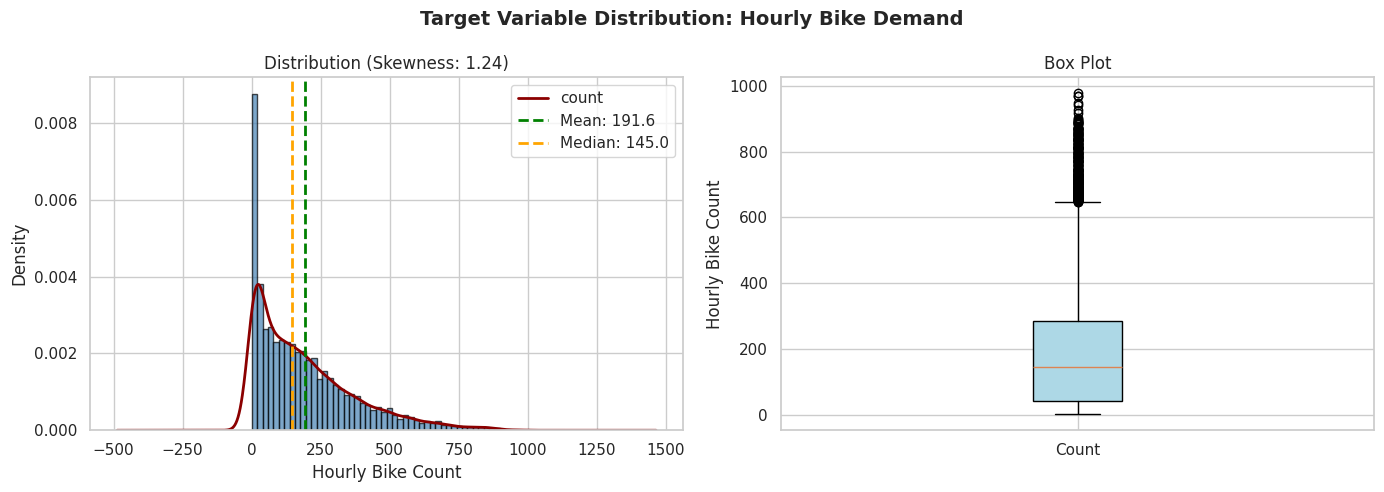

In [7]:
count_stats = df["count"].describe()
count_skewness = skew(df["count"])
count_kurtosis = kurtosis(df["count"])
normal_stat, normal_p = normaltest(df["count"])

print("Target variable: hourly bike demand (`count`)")
print(f"Mean: {count_stats['mean']:.1f} bikes/hour")
print(f"Median: {count_stats['50%']:.1f} bikes/hour")
print(f"Standard deviation: {count_stats['std']:.1f}")
print(f"Range: {count_stats['min']:.0f} to {count_stats['max']:.0f}")
print(f"Skewness: {count_skewness:.3f}")
print(f"Kurtosis: {count_kurtosis:.3f}")
print(f"Normality test p-value: {normal_p:.2e}")

registered_pct = df["registered"].sum() / df["count"].sum() * 100
casual_pct = df["casual"].sum() / df["count"].sum() * 100
print(f"Registered users: {registered_pct:.1f}% of demand")
print(f"Casual users: {casual_pct:.1f}% of demand")

fig_target, axes_target = plt.subplots(1, 2, figsize=(14, 5))
fig_target.suptitle('Target Variable Distribution: Hourly Bike Demand', fontsize=14, fontweight='bold')

axes_target[0].hist(df['count'], bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
df['count'].plot(kind='kde', ax=axes_target[0], color='darkred', linewidth=2)
axes_target[0].axvline(df['count'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df["count"].mean():.1f}')
axes_target[0].axvline(df['count'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["count"].median():.1f}')
axes_target[0].set_xlabel('Hourly Bike Count')
axes_target[0].set_ylabel('Density')
axes_target[0].set_title(f'Distribution (Skewness: {count_skewness:.2f})')
axes_target[0].legend()

box_target = axes_target[1].boxplot([df['count']], patch_artist=True)
box_target['boxes'][0].set_facecolor('lightblue')
axes_target[1].set_ylabel('Hourly Bike Count')
axes_target[1].set_title('Box Plot')
axes_target[1].set_xticklabels(['Count'])

plt.tight_layout()
plt.show()

### Target Variable Analysis - Key Findings:

**Distribution Characteristics:**

* Right-skewed distribution (skewness ≈ 1.24)
Mean > Median indicates positive skew (presence of high-demand peaks)
* Wide range: 1 to 977 bikes per hour
* High variability: Standard deviation ≈ 181 bikes/hour

**Statistical Implications:**

* Non-normal distribution violates assumptions for parametric tests (ANOVA, t-test)
* We will use non-parametric tests (Kruskal-Wallis, Mann-Whitney U) instead
* Random Forest models are robust to non-normality

**User Composition:**

* Registered users dominate (~81% of demand)
Indicates strong commuter/subscription base
* Business should focus on retaining registered users

## 5. Multivariate Analysis - Temporal Trends Analysis

---

Year-over-year demand


,mean,sum,count
year,,,
2011,144.223,781979,5422
2012,238.575,1303333,5463


Average hourly demand grew by 65.4% from 2011 to 2012.


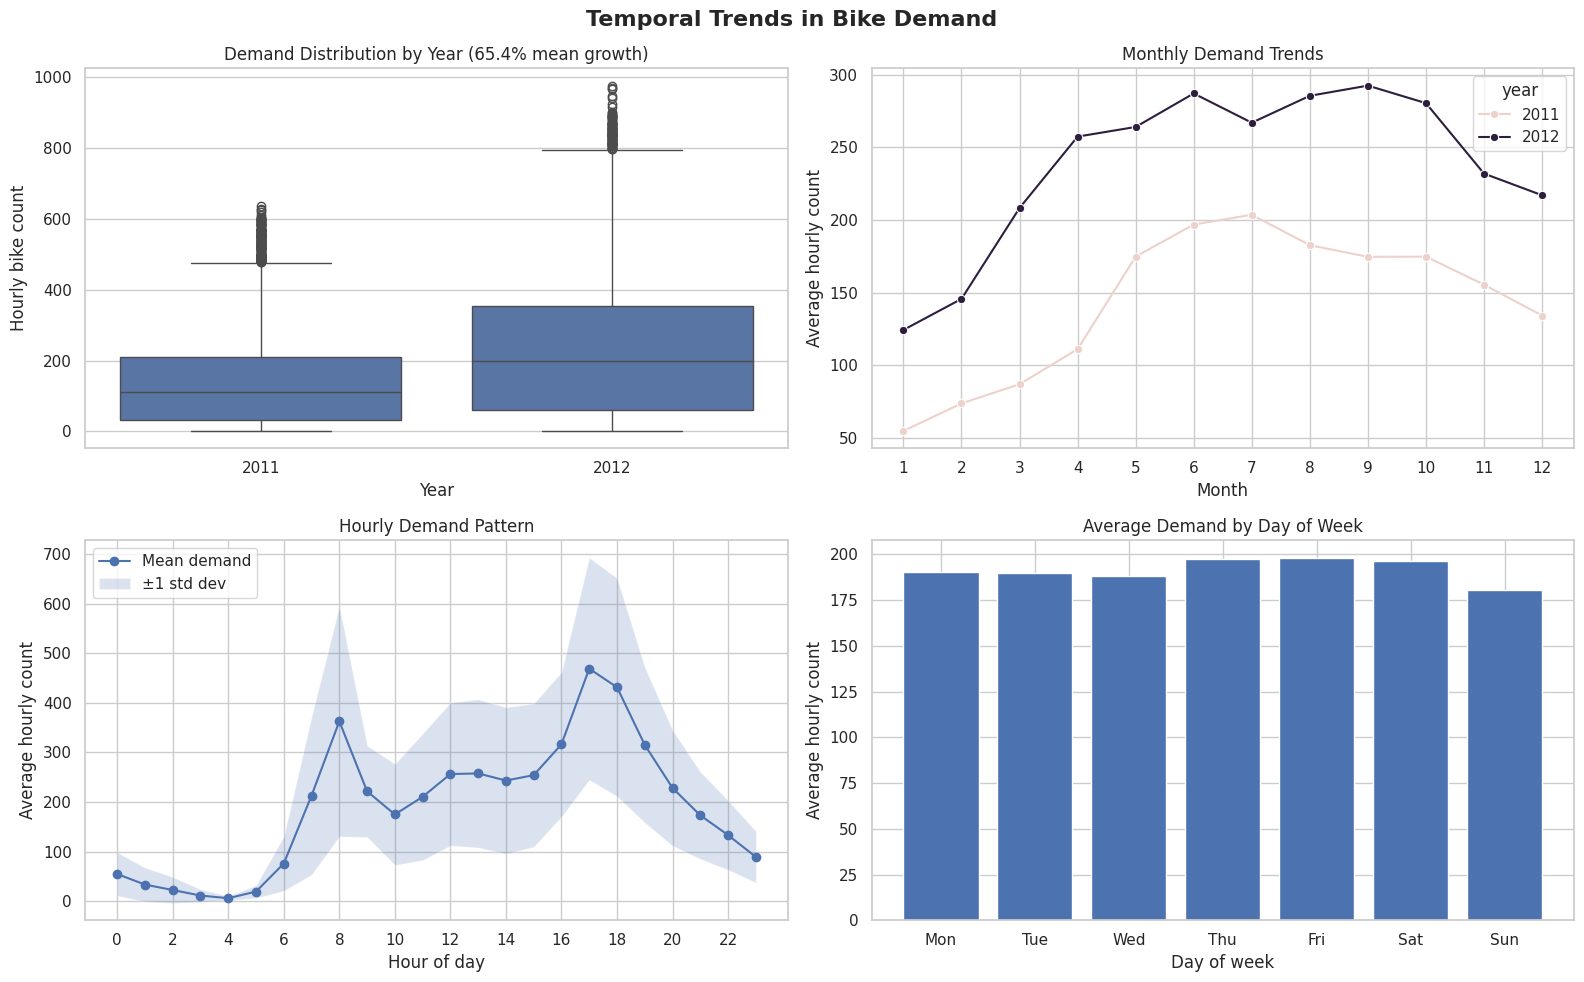

In [8]:
yearly_stats = df.groupby("year", observed=True)["count"].agg(["mean", "sum", "count"])
yoy_growth_rate = (yearly_stats.loc[2012, "mean"] - yearly_stats.loc[2011, "mean"]) / yearly_stats.loc[2011, "mean"] * 100

monthly_demand_by_year = df.groupby(["year", "month"], observed=True)["count"].mean().reset_index()
hourly_demand_stats = df.groupby("hour", observed=True)["count"].agg(["mean", "std"]).reset_index()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_demand = df.groupby("day_name", observed=True)["count"].mean().reindex(day_order)

print("Year-over-year demand")
display(yearly_stats)
print(f"Average hourly demand grew by {yoy_growth_rate:.1f}% from 2011 to 2012.")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Temporal Trends in Bike Demand", fontsize=16, fontweight="bold")

sns.boxplot(data=df, x="year", y="count", ax=axes[0, 0])
axes[0, 0].set_title(f"Demand Distribution by Year ({yoy_growth_rate:.1f}% mean growth)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Hourly bike count")

sns.lineplot(data=monthly_demand_by_year, x="month", y="count", hue="year", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Monthly Demand Trends")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Average hourly count")
axes[0, 1].set_xticks(range(1, 13))

axes[1, 0].plot(hourly_demand_stats["hour"], hourly_demand_stats["mean"], marker="o", label="Mean demand")
axes[1, 0].fill_between(
    hourly_demand_stats["hour"],
    hourly_demand_stats["mean"] - hourly_demand_stats["std"],
    hourly_demand_stats["mean"] + hourly_demand_stats["std"],
    alpha=0.2,
    label="±1 std dev",
)
axes[1, 0].set_title("Hourly Demand Pattern")
axes[1, 0].set_xlabel("Hour of day")
axes[1, 0].set_ylabel("Average hourly count")
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].legend()

axes[1, 1].bar(range(7), weekday_demand.values)
axes[1, 1].set_title("Average Demand by Day of Week")
axes[1, 1].set_xlabel("Day of week")
axes[1, 1].set_ylabel("Average hourly count")
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels([day[:3] for day in day_order])

plt.tight_layout()
plt.show()

In [9]:
peak_hours = hourly_demand_stats.nlargest(3, "mean")
low_demand_hours = hourly_demand_stats.nsmallest(3, "mean")
morning_avg = hourly_demand_stats.loc[hourly_demand_stats["hour"].isin([7, 8, 9]), "mean"].mean()
evening_avg = hourly_demand_stats.loc[hourly_demand_stats["hour"].isin([17, 18, 19]), "mean"].mean()

print("Peak demand hours")
display(peak_hours.assign(hour=lambda x: x["hour"].astype(int)).reset_index(drop=True))

print("\nLowest demand hours")
display(low_demand_hours.assign(hour=lambda x: x["hour"].astype(int)).reset_index(drop=True))

print(f"\nMorning peak average (7-9am): {morning_avg:.1f} bikes/hour")
print(f"Evening peak average (5-7pm): {evening_avg:.1f} bikes/hour")
print(f"Evening peak is {(evening_avg / morning_avg - 1) * 100:.0f}% higher than the morning peak.")

Peak demand hours


,hour,mean,std
0,17,468.765,223.775
1,18,431.446,219.793
2,8,362.769,231.723



Lowest demand hours


,hour,mean,std
0,4,6.407,4.218
1,3,11.758,12.666
2,5,19.768,12.784



Morning peak average (7-9am): 265.9 bikes/hour
Evening peak average (5-7pm): 405.2 bikes/hour
Evening peak is 52% higher than the morning peak.


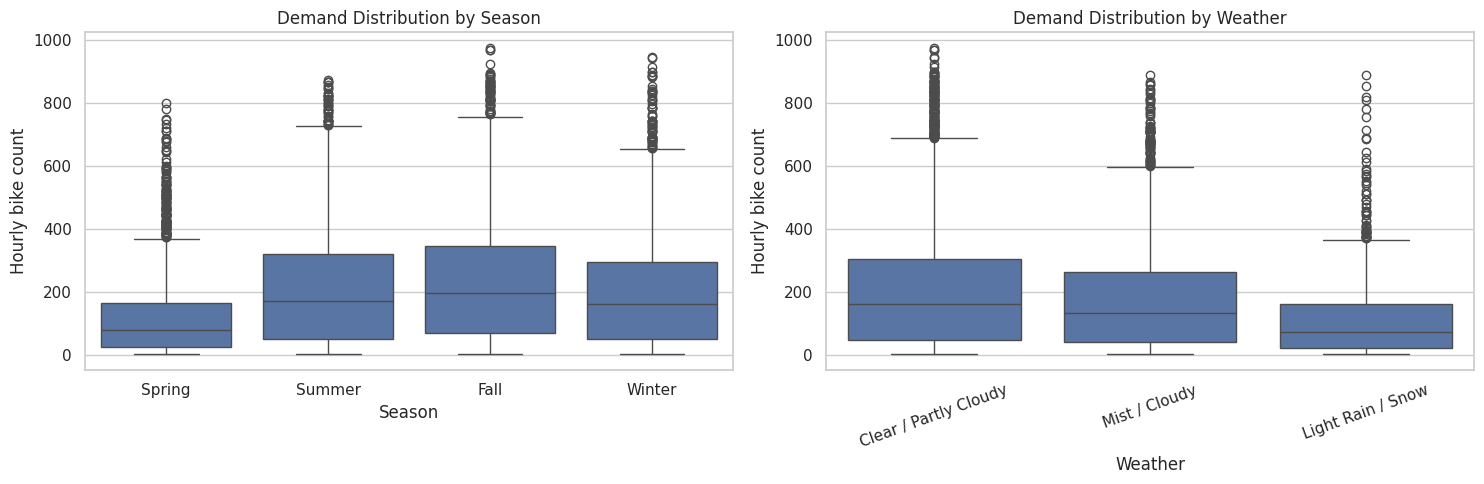

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

season_order = ["Spring", "Summer", "Fall", "Winter"]
sns.boxplot(data=df, x="season_name", y="count", order=season_order, ax=axes[0])
axes[0].set_title("Demand Distribution by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Hourly bike count")

weather_order = ["Clear / Partly Cloudy", "Mist / Cloudy", "Light Rain / Snow"]
sns.boxplot(data=df, x="weather_name", y="count", order=weather_order, ax=axes[1])
axes[1].set_title("Demand Distribution by Weather")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("Hourly bike count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

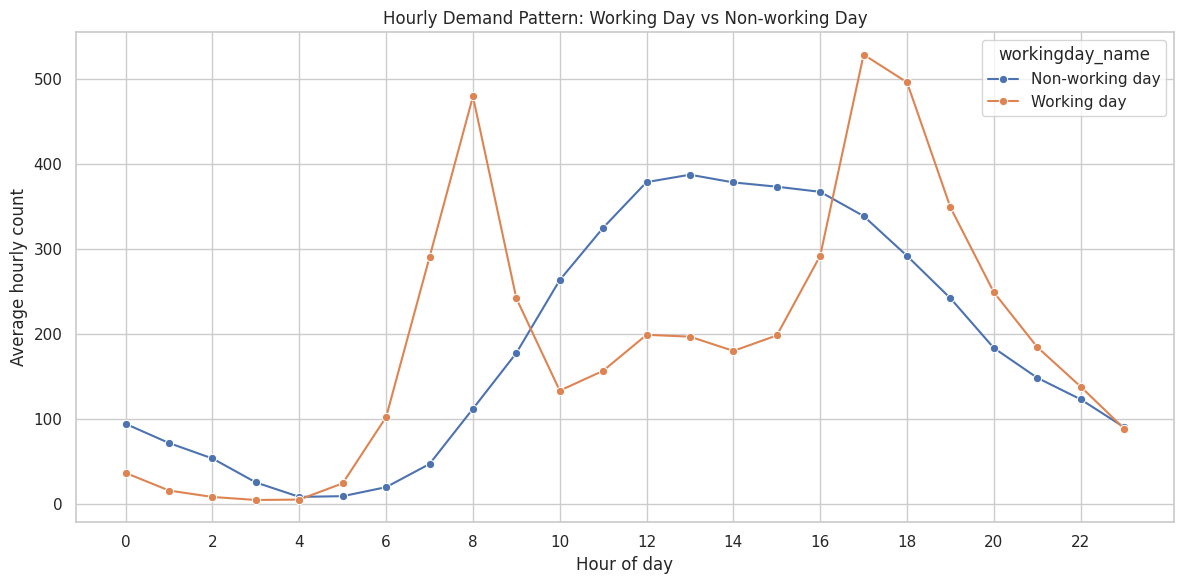

In [11]:
# Working day might not itself be significant overall, but its interaction with hour is operationally critical.
hourly_by_workday = df.groupby(["hour", "workingday_name"], observed=True)["count"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=hourly_by_workday, x="hour", y="count", hue="workingday_name", marker="o", ax=ax)
ax.set_title("Hourly Demand Pattern: Working Day vs Non-working Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average hourly count")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

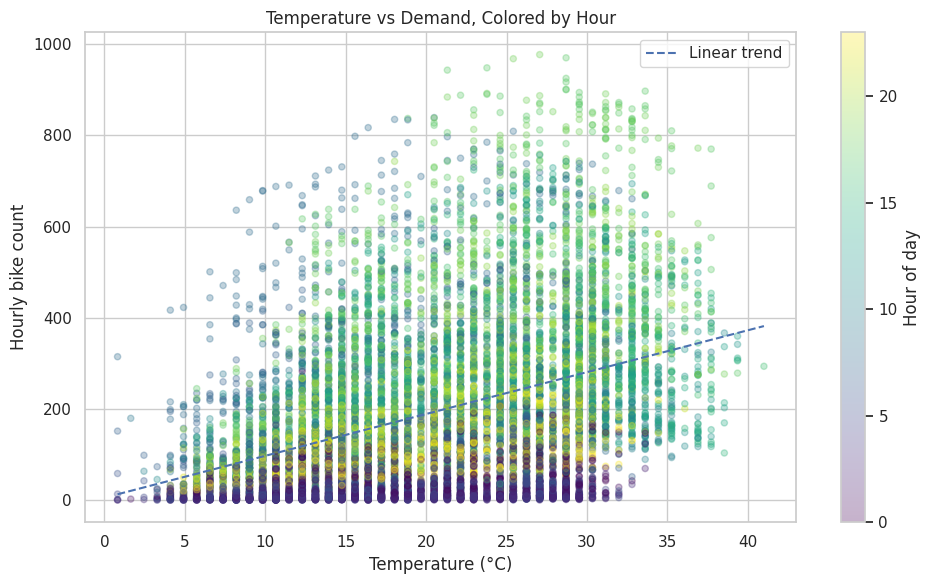

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df["temp"], df["count"], alpha=0.3, s=20, c=df["hour"], cmap="viridis")
coef = np.polyfit(df["temp"], df["count"], 1)
trend = np.poly1d(coef)
temp_grid = np.linspace(df["temp"].min(), df["temp"].max(), 100)
ax.plot(temp_grid, trend(temp_grid), linestyle="--", label="Linear trend")
ax.set_title("Temperature vs Demand, Colored by Hour")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Hourly bike count")
ax.legend()
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Hour of day")
plt.tight_layout()
plt.show()

### Temporal Trends - Key Findings:

**Strong Growth Trajectory:**
* 65% increase in average hourly demand from 2011 to 2012
* Indicates successful market penetration and service adoption
* Both user types (casual and registered) contributing to growth

**Seasonal Patterns:**
* Demand peaks in summer and fall months (May-October)
* Spring shows lowest demand (reflects US climate, not Indian monsoon)
* Clear weather-dependent seasonal cycle

**Hourly Patterns (Critical for Operations):**
* Evening peak (5-6pm) is the highest demand period: ~450-470 bikes/hour
* Morning rush (8-9am) shows secondary peak: ~360 bikes/hour
* Evening demand is ~52% higher than morning peak
* Minimum demand during late night/early morning (4-5am): ~6-20 bikes/hour

**Weekday Patterns:**
* Overall volume similar between weekdays and weekends
* Pattern differs: bimodal (commute) peaks on weekdays vs. single broad peak on weekends

**Season Effect:**
* Fall shows highest median and wider upper range; Spring shows lowest demand

**Weather Effect:**
* Clear weather has highest demand; rain/snow significantly reduces usage

**Hour × Working Day:**
* Fundamentally different patterns require different operational strategies

**Temperature:**
* Positive trend, but hour-of-day explains more variance (color gradient shows strong vertical stratification)

---


**Operational Implications:**

* Scale capacity 25× from night to evening peak
* Reduce operations during late night/early morning (midnight-5am)
* Plan seasonal inventory adjustments (±40% from low to high season)
* Rebalancing strategy should account for one-way commute flows

## 6. Categorical Predictors - Hypothesis Testing

---

Research Question: Do different `seasons/weather/workingday/holiday` have significantly different demand levels?

Hypotheses:

H₀ (Null): All `seasons/weather/workingday/holiday` have the same median demand

H₁ (Alternative): At least one `seasons/weather/workingday/holiday` differs significantly

---

Because `count` is right-skewed and the normality test rejects normality, we use non-parametric tests:

- Kruskal-Wallis for multi-level categorical variables (`season`, `weather`),
- Mann-Whitney U for binary categorical variables (`workingday`, `holiday`),

Effect sizes are reported so that large-sample statistical significance is not confused with business impact.

In [13]:
# Reusable functions
def epsilon_squared_kruskal(h_stat: float, n: int) -> float:
    """Approximate epsilon-squared effect size for Kruskal-Wallis."""
    return h_stat / (n - 1)


def interpret_epsilon_squared(value: float) -> str:
    if value < 0.01:
        return "negligible"
    if value < 0.06:
        return "small"
    if value < 0.14:
        return "medium"
    return "large"


def interpret_rank_biserial(value: float) -> str:
    abs_value = abs(value)
    if abs_value < 0.10:
        return "negligible"
    if abs_value < 0.30:
        return "small"
    if abs_value < 0.50:
        return "medium"
    return "large"


def pairwise_mannwhitney_holm(data: pd.DataFrame, group_col: str, target_col: str, labels: dict | None = None) -> pd.DataFrame:
    """Pairwise Mann-Whitney U tests with Holm correction."""
    groups = sorted(data[group_col].dropna().unique())
    rows = []
    for a, b in combinations(groups, 2):
        x = data.loc[data[group_col] == a, target_col]
        y = data.loc[data[group_col] == b, target_col]
        u_stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
        rows.append({"group_a": a, "group_b": b, "u_statistic": u_stat, "p_value": p_value})

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    reject, p_adjusted, _, _ = multipletests(out["p_value"], alpha=0.05, method="holm")
    out["p_adjusted_holm"] = p_adjusted
    out["reject_null_0.05"] = reject
    if labels:
        out["group_a"] = out["group_a"].map(labels)
        out["group_b"] = out["group_b"].map(labels)
    return out

In [14]:
# Season effect
season_stats = df.groupby("season", observed=True)["count"].agg(["mean", "median", "std", "count"])
season_stats.index = season_stats.index.map(season_labels)
season_groups = [df.loc[df["season"] == season, "count"] for season in sorted(season_labels)]
season_h, season_p = kruskal(*season_groups)
season_eps = epsilon_squared_kruskal(season_h, len(df))

print("Demand by season")
display(season_stats)
print(f"Kruskal-Wallis H: {season_h:.2f}")
print(f"p-value: {season_p:.2e}")
print(f"Epsilon-squared: {season_eps:.4f} ({interpret_epsilon_squared(season_eps)} effect)")

season_posthoc = pairwise_mannwhitney_holm(df, "season", "count", season_labels)
print("\nPairwise season comparisons with Holm-adjusted p-values")
display(season_posthoc)

Demand by season


,mean,median,std,count
season,,,,
Spring,116.326,78.000,125.294,2685
Summer,215.251,172.000,192.008,2733
Fall,234.417,195.000,197.151,2733
Winter,198.988,161.000,177.622,2734


Kruskal-Wallis H: 699.88
p-value: 2.23e-151
Epsilon-squared: 0.0643 (medium effect)

Pairwise season comparisons with Holm-adjusted p-values


,group_a,group_b,u_statistic,p_value,p_adjusted_holm,reject_null_0.05
0,Spring,Summer,"2,517,259.000",0.000,0.000,True
1,Spring,Fall,"2,271,121.000",0.000,0.000,True
2,Spring,Winter,"2,593,663.000",0.000,0.000,True
3,Summer,Fall,"3,498,667.500",0.000,0.000,True
4,Summer,Winter,"3,875,221.000",0.017,0.017,True
5,Fall,Winter,"4,123,318.000",0.000,0.000,True


### Season effect Findings

* **Objective:** Test whether bike demand (`count`) differs across seasons: Spring, Summer, Fall, and Winter.

* **Why Kruskal-Wallis was used:**

  * Demand/count data is usually skewed, non-normal.
  * Kruskal-Wallis is a non-parametric alternative to ANOVA.
  * It compares **rank distributions**, not raw means.

* **Hypothesis:**

  * H₀ (Null) = Demand distribution is the same across all seasons.
  * H₁ (Alternative) = At least one season has a different demand distribution.

* **Season summary:**

  * Spring has the lowest demand.
  * Fall has the highest demand.
  * Summer and Winter are in the middle.
  * Median demand ranking:
    `Spring < Winter < Summer < Fall`

* **Kruskal-Wallis result:**

  * `H = 699.88`
  * `p-value = 2.23e-151`
  * Since the p-value is extremely small, we reject the null hypothesis.
  * This means demand differs significantly across seasons.

* **Effect size:**

  * `Epsilon-squared = 0.0643`
  * This suggests a **medium effect**.
  * Season explains a meaningful, but not dominant, portion of demand variation.

* **Why pairwise tests were done:**

  * Kruskal-Wallis only tells us that some seasonal difference exists.
  * It does not tell us which seasons differ from each other.
  * Pairwise Mann-Whitney U tests were used to compare seasons two at a time.

* **Why Holm correction was applied:**

  * There are 6 pairwise comparisons.
  * Multiple testing increases the chance of false positives.
  * Holm adjustment controls this risk.

* **Pairwise comparison result:**

  * All season pairs are significantly different after Holm adjustment.
  * Spring differs significantly from Summer, Fall, and Winter.
  * Fall differs significantly from Summer and Winter.
  * Summer and Winter are also significantly different, though this is the weakest comparison.

* **Practical interpretation:**

  * Season is a meaningful predictor of bike demand.
  * Spring demand is clearly the lowest.
  * Fall demand is the highest.
  * Summer and Winter are closer to each other but still statistically different.

* **Modeling implication:**

  * `season` should be included as a feature in demand modeling.
  * However, season alone does not explain demand fully.
  * Other variables such as hour, temperature, weather, working day, holiday, humidity, and windspeed are also likely important.

* **Final conclusion:**

  * Bike demand varies significantly by season.
  * The seasonal effect is statistically strong and practically moderate.
  * Seasonality matters, but it is only one part of the overall demand pattern.


In [15]:
# Weather effect
weather_stats = df.groupby("weather", observed=True)["count"].agg(["mean", "median", "std", "count"])
weather_stats.index = weather_stats.index.map(weather_labels)
weather_groups = [df.loc[df["weather"] == weather, "count"] for weather in [1, 2, 3]]
weather_h, weather_p = kruskal(*weather_groups)
weather_eps = epsilon_squared_kruskal(weather_h, len(df))

clear_mean = weather_stats.loc["Clear / Partly Cloudy", "mean"]
rain_mean = weather_stats.loc["Light Rain / Snow", "mean"]
clear_vs_rain_lift = (clear_mean / rain_mean - 1) * 100

print("Demand by weather")
display(weather_stats)
print(f"Kruskal-Wallis H: {weather_h:.2f}")
print(f"p-value: {weather_p:.2e}")
print(f"Epsilon-squared: {weather_eps:.4f} ({interpret_epsilon_squared(weather_eps)} effect)")
print(f"Clear/partly-cloudy demand is {clear_vs_rain_lift:.0f}% higher than light-rain/snow demand.")

weather_posthoc = pairwise_mannwhitney_holm(df, "weather", "count", weather_labels)
print("\nPairwise weather comparisons with Holm-adjusted p-values")
display(weather_posthoc)

Demand by weather


,mean,median,std,count
weather,,,,
Clear / Partly Cloudy,205.237,161.000,187.960,7192
Mist / Cloudy,178.956,134.000,168.366,2834
Light Rain / Snow,118.846,71.000,138.581,859


Kruskal-Wallis H: 204.96
p-value: 3.12e-45
Epsilon-squared: 0.0188 (small effect)
Clear/partly-cloudy demand is 73% higher than light-rain/snow demand.

Pairwise weather comparisons with Holm-adjusted p-values


,group_a,group_b,u_statistic,p_value,p_adjusted_holm,reject_null_0.05
0,Clear / Partly Cloudy,Mist / Cloudy,"10,906,755.000",0.000,0.000,True
1,Clear / Partly Cloudy,Light Rain / Snow,"3,980,116.000",0.000,0.000,True
2,Mist / Cloudy,Light Rain / Snow,"1,497,645.000",0.000,0.000,True


### Weather effect Findings

* **Objective:** Test whether bike demand (`count`) differs across weather conditions: Clear/Partly Cloudy, Mist/Cloudy, and Light Rain/Snow.

* **Why Kruskal-Wallis was used:**

  * Bike demand is count-based and skewed.
  * Weather groups may have unequal variance and outliers.
  * Kruskal-Wallis is a non-parametric alternative to ANOVA.
  * It compares **rank distributions** across weather groups rather than raw means.

* **Hypothesis:**

  * H₀ (Null) = Demand distribution is the same across all weather conditions.
  * H₁ (Alternative) = At least one weather condition has a different demand distribution.

* **Weather summary:**

  * Demand is highest during Clear/Partly Cloudy weather.
  * Demand decreases during Mist/Cloudy weather.
  * Demand is lowest during Light Rain/Snow.
  * Median demand ranking:
    `Light Rain / Snow < Mist / Cloudy < Clear / Partly Cloudy`

* **Kruskal-Wallis result:**

  * `H = 204.96`
  * `p-value = 3.12e-45`
  * Since the p-value is extremely small, we reject the null hypothesis.
  * This means demand differs significantly across weather conditions.

* **Effect size:**

  * `Epsilon-squared = 0.0188`
  * This suggests a **small effect**.
  * Weather has a statistically significant impact on demand, but it explains only a small portion of total demand variation.

* **Demand lift interpretation:**

  * Mean demand during Clear/Partly Cloudy weather is `205.237`.
  * Mean demand during Light Rain/Snow is `118.846`.
  * Clear/Partly Cloudy demand is approximately **73% higher** than Light Rain/Snow demand.
  * This shows that poor weather meaningfully reduces bike demand.

* **Why pairwise tests were done:**

  * Kruskal-Wallis tells us that demand differs somewhere across weather groups.
  * It does not tell us which specific weather groups differ.
  * Pairwise Mann-Whitney U tests were used to compare weather conditions two at a time.

* **Why Holm correction was applied:**

  * There are 3 pairwise comparisons.
  * Multiple testing increases the chance of false positives.
  * Holm adjustment controls this risk.

* **Pairwise comparison result:**

  * All weather pairs are significantly different after Holm adjustment.
  * Clear/Partly Cloudy differs significantly from Mist/Cloudy.
  * Clear/Partly Cloudy differs significantly from Light Rain/Snow.
  * Mist/Cloudy differs significantly from Light Rain/Snow.

* **Practical interpretation:**

  * Better weather is associated with higher bike demand.
  * Bad weather, especially Light Rain/Snow, is associated with much lower demand.
  * However, the overall effect size is small, meaning weather alone does not explain most of the variation in demand.

* **Modeling implication:**

  * `weather` should be included as a feature in demand modeling.
  * It captures a real and statistically significant demand pattern.
  * However, it should be combined with stronger predictors such as hour, temperature, season, working day, holiday, humidity, and windspeed.

* **Final conclusion:**

  * Bike demand varies significantly by weather condition.
  * Demand is highest in Clear/Partly Cloudy weather and lowest in Light Rain/Snow.
  * The weather effect is statistically strong but practically small.
  * Weather matters, but it is only one part of the overall demand pattern.


In [16]:
# Workingday & Holiday effect
def binary_mannwhitney_summary(data: pd.DataFrame, group_col: str, target_col: str, labels: dict) -> tuple[pd.DataFrame, dict]:
    stats_table = data.groupby(group_col, observed=True)[target_col].agg(["mean", "median", "std", "count"])
    stats_table.index = stats_table.index.map(labels)
    g0 = data.loc[data[group_col] == 0, target_col]
    g1 = data.loc[data[group_col] == 1, target_col]
    u_stat, p_value = mannwhitneyu(g1, g0, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(g1) * len(g0))
    result = {
        "u_statistic": u_stat,
        "p_value": p_value,
        "rank_biserial": rank_biserial,
        "effect_interpretation": interpret_rank_biserial(rank_biserial),
    }
    return stats_table, result

for group_col, labels in [("workingday", workingday_labels), ("holiday", holiday_labels)]:
    stats_table, result = binary_mannwhitney_summary(df, group_col, "count", labels)
    print(f"Demand by {group_col}")
    display(stats_table)
    print(f"Mann-Whitney U: {result['u_statistic']:.2f}")
    print(f"p-value: {result['p_value']:.3f}")
    print(f"Rank-biserial correlation: {result['rank_biserial']:.4f} ({result['effect_interpretation']} effect)")
    print("-" * 80)

Demand by workingday


,mean,median,std,count
workingday,,,,
Non-working day,188.507,128.000,173.724,3474
Working day,193.016,151.000,184.526,7411


Mann-Whitney U: 12866542.50
p-value: 0.967
Rank-biserial correlation: 0.0005 (negligible effect)
--------------------------------------------------------------------------------
Demand by holiday


,mean,median,std,count
holiday,,,,
Non-holiday,191.744,145.000,181.522,10574
Holiday,185.878,133.000,168.301,311


Mann-Whitney U: 1634961.00
p-value: 0.865
Rank-biserial correlation: 0.0057 (negligible effect)
--------------------------------------------------------------------------------


### Workingday & Holiday effect Findings

**Objective:** Test whether bike demand (`count`) differs based on:

  * `workingday`: Working day vs Non-working day
  * `holiday`: Holiday vs Non-holiday

---

**Working Day Effect**

* **Why Mann-Whitney U was used:**

  * `workingday` has only two groups: Working day and Non-working day.
  * Since demand/count data is skewed and non-normal, Mann-Whitney U is preferred over a two-sample t-test.
  * It compares the **rank distributions** of demand between the two groups, not just the raw means.

* **Hypothesis:**

  * H₀ (Null) = Demand distribution is the same on working days and non-working days.
  * H₁ (Alternative) = Demand distribution differs between working days and non-working days.
  

* **Working day summary:**

  * Mean demand is slightly higher on working days.
  * Median demand is also higher on working days.
  * However, the difference is very small.
  * Median demand ranking:
    `Non-working day < Working day`

* **Mann-Whitney U result:**

  * `U = 12,866,542.50`
  * `p-value = 0.967`
  * Since the p-value is much greater than 0.05, we fail to reject the null hypothesis.
  * This means there is no statistically significant difference in demand between working days and non-working days.

* **Effect size:**

  * `Rank-biserial correlation = 0.0005`
  * This indicates a **negligible effect**.
  * The working-day variable does not meaningfully separate demand levels.

* **Practical interpretation:**

  * Although working days have a slightly higher median demand, the difference is not statistically meaningful.
  * Demand appears broadly similar between working and non-working days.
  * `workingday` alone does not explain much variation in bike demand.

---

**Holiday Effect**

* **Why Mann-Whitney U was used:**

  * `holiday` has only two groups: Holiday and Non-holiday.
  * Mann-Whitney U is appropriate because demand is skewed and count-based.
  * It compares rank distributions between holiday and non-holiday observations.

* **Hypothesis:**

  * H₀ (Null) = Demand distribution is the same on holidays and non-holidays.
  * H₁ (Alternative) = Demand distribution differs between holidays and non-holidays.

* **Holiday summary:**

  * Mean demand is slightly lower on holidays.
  * Median demand is also slightly lower on holidays.
  * However, the difference is very small.
  * Median demand ranking:
    `Holiday < Non-holiday`

* **Mann-Whitney U result:**

  * `U = 1,634,961.00`
  * `p-value = 0.865`
  * Since the p-value is much greater than 0.05, we fail to reject the null hypothesis.
  * This means there is no statistically significant difference in demand between holidays and non-holidays.

* **Effect size:**

  * `Rank-biserial correlation = 0.0057`
  * This indicates a **negligible effect**.
  * Holiday status does not meaningfully explain demand differences.

* **Practical interpretation:**

  * Demand is slightly lower on holidays, but the difference is not statistically meaningful.
  * The holiday group is also much smaller than the non-holiday group, so holiday-level conclusions should be interpreted carefully.
  * `holiday` alone does not appear to be an important demand separator.

---

**Overall Interpretation**

* **Both `workingday` and `holiday` show no statistically significant difference in demand.**

* **Working day result:**

  * `p-value = 0.967`
  * Negligible effect size.
  * Demand is not meaningfully different between working and non-working days.

* **Holiday result:**

  * `p-value = 0.865`
  * Negligible effect size.
  * Demand is not meaningfully different between holidays and non-holidays.

* **Modeling implication:**

  * `workingday` and `holiday` may not be strong standalone predictors of bike demand.
  * However, they may still be useful in interaction with other variables, especially:

    * `hour`
    * `season`
    * `weather`
    * `temperature`
    * `weekday`
  * For example, working days may matter more during commute hours, while holidays may affect demand differently depending on season or weather.

* **Final conclusion:**

  * Bike demand does not differ significantly by working day or holiday status in this dataset.
  * Both variables show negligible standalone effects.
  * They should not be interpreted as major independent drivers of demand, but they may still provide value when combined with time-based or weather-related features.


## 7. Continuous Predictors - Correlation, Leakage, and Multicollinearity

---

Spearman/Pearson correlations calculated for continuous predictors.

* `casual` and `registered` are excluded from predictive modeling because `count = casual + registered`. Including them would leak the target.

* `temp` and `atemp` are almost duplicate temperature measures. The final model uses `temp` and excludes `atemp` to reduce redundancy.

Correlation with target, including target components for leakage demonstration


,pearson_corr_with_count
registered,0.971
casual,0.690
temp,0.394
atemp,0.390
windspeed,0.101
humidity,-0.317



Predictive continuous variables only


,variable,pearson_corr,spearman_corr
0,temp,0.394,0.408
1,atemp,0.390,0.407
2,humidity,-0.317,-0.354
3,windspeed,0.101,0.136


temp-atemp correlation: 0.985
`casual` and `registered` are target components and are excluded from modeling.
`atemp` is excluded from modeling due to near-perfect correlation with `temp`.



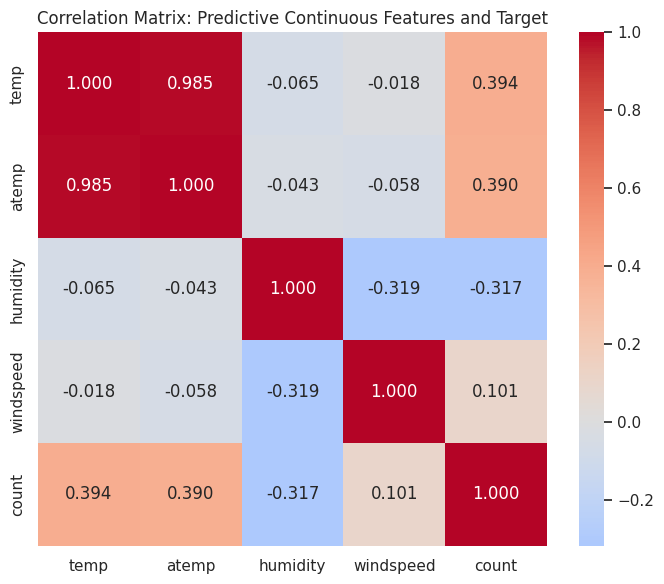

In [17]:
continuous_vars_all = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
correlation_matrix = df[continuous_vars_all].corr()
correlation_to_count = correlation_matrix["count"].drop("count").sort_values(ascending=False)

corr_rows = []
for var in ["temp", "atemp", "humidity", "windspeed"]:
    pearson = df[var].corr(df["count"])
    spearman = spearmanr(df[var], df["count"]).correlation
    corr_rows.append({"variable": var, "pearson_corr": pearson, "spearman_corr": spearman})

print("Correlation with target, including target components for leakage demonstration")
display(correlation_to_count.to_frame("pearson_corr_with_count"))

print("\nPredictive continuous variables only")
display(pd.DataFrame(corr_rows))

print(f"temp-atemp correlation: {correlation_matrix.loc['temp', 'atemp']:.3f}")
print("`casual` and `registered` are target components and are excluded from modeling.")
print("`atemp` is excluded from modeling due to near-perfect correlation with `temp`.\n")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[["temp", "atemp", "humidity", "windspeed", "count"]].corr(), annot=True, fmt=".3f", center=0, cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix: Predictive Continuous Features and Target")
plt.tight_layout()
plt.show()

### Continuous Predictors - Key Findings


| Variable     | Correlation with `count` | Strength                      | Modeling Decision                            |
| ------------ | -----------------------: | ----------------------------- | -------------------------------------------- |
| `temp`       |                 r ≈ 0.39 | Moderate positive correlation | Include in models                            |
| `atemp`      |                 r ≈ 0.39 | Moderate positive correlation | Exclude due to multicollinearity with `temp` |
| `humidity`   |                r ≈ -0.32 | Moderate negative correlation | Include in models                            |
| `windspeed`  |                 r ≈ 0.10 | Weak positive correlation     | Include in models                            |
| `registered` |                 r ≈ 0.97 | Very strong correlation       | Exclude due to target leakage                |
| `casual`     |                 r ≈ 0.69 | Strong correlation            | Exclude due to target leakage                |


**Variables Excluded from Modeling**

* `casual` and `registered` were excluded because they are direct components of the target variable `count`, which would create target leakage.
* `atemp` was excluded because it is almost perfectly correlated with `temp` *(r ≈ 0.985)*, creating multicollinearity.
* `temp`, `humidity`, and `windspeed` were retained because they provide useful weather-related information without directly leaking the target.


## 8. Predictive Modeling

---

Modeling choices:

- Exclude `casual` and `registered` to avoid target leakage.
- Exclude `atemp` because it is nearly collinear with `temp`.
- Use a chronological 80/20 split rather than a random split to avoid future-data leakage.
- Compare predictive models with simple operational baselines.

In [18]:
modeling_columns = [
    "season", "holiday", "workingday", "weather", "temp", "humidity", "windspeed",
    "hour", "weekday", "month", "year",
]

# Sort chronologically before splitting.
df_model = df.sort_values("datetime").reset_index(drop=True)
X = df_model[modeling_columns].copy()
y = df_model["count"].copy()

split_idx = int(len(df_model) * 0.80)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
train_period = (df_model.loc[:split_idx - 1, "datetime"].min(), df_model.loc[:split_idx - 1, "datetime"].max())
test_period = (df_model.loc[split_idx:, "datetime"].min(), df_model.loc[split_idx:, "datetime"].max())

print(f"Training set: {len(X_train):,} rows ({len(X_train) / len(df_model):.1%}), {train_period[0]} to {train_period[1]}")
print(f"Test set: {len(X_test):,} rows ({len(X_test) / len(df_model):.1%}), {test_period[0]} to {test_period[1]}")

numeric_features = ["holiday", "workingday", "temp", "humidity", "windspeed", "year"]
categorical_features = ["season", "weather", "hour", "weekday", "month"]
category_domains = [
    [1, 2, 3, 4],        # season
    [1, 2, 3],           # weather after excluding weather=4
    list(range(24)),     # hour
    list(range(7)),      # weekday
    list(range(1, 13)),  # month
]

# Linear models scale the entire encoded feature matrix to match regularization behavior.
def make_preprocessor_for_linear() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat", OneHotEncoder(categories=category_domains, drop="first", handle_unknown="ignore", sparse_output=False), categorical_features),
        ],
        remainder="drop",
    )

# Tree models do not require scaling.
def make_preprocessor_for_tree() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat", OneHotEncoder(categories=category_domains, drop="first", handle_unknown="ignore", sparse_output=False), categorical_features),
        ],
        remainder="drop",
    )

models = {
    "Linear Regression": Pipeline([
        ("preprocess", make_preprocessor_for_linear()),
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("preprocess", make_preprocessor_for_linear()),
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", make_preprocessor_for_tree()),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

Training set: 8,708 rows (80.0%), 2011-01-01 00:00:00 to 2012-08-05 05:00:00
Test set: 2,177 rows (20.0%), 2012-08-05 06:00:00 to 2012-12-19 23:00:00


In [19]:
def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    return {
        "r2": r2_score(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
    }

model_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)
    model_results[name] = {
        "model": model,
        "train_pred": train_pred,
        "test_pred": test_pred,
        "train_r2": train_metrics["r2"],
        "test_r2": test_metrics["r2"],
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
    }

model_results_df = (
    pd.DataFrame(model_results)
    .T[["train_r2", "test_r2", "test_rmse", "test_mae"]]
    .sort_values("test_r2", ascending=False)
)
display(model_results_df)

best_model_name = model_results_df.index[0]
best_model = model_results[best_model_name]["model"]
print(f"\nBest model on chronological test set: {best_model_name}")
print(f"Test R²: {model_results[best_model_name]['test_r2']:.4f}")
print(f"Test RMSE: {model_results[best_model_name]['test_rmse']:.2f}")
print(f"Test MAE: {model_results[best_model_name]['test_mae']:.2f}")

,train_r2,test_r2,test_rmse,test_mae
Random Forest,0.918,0.736,111.718,78.366
Linear Regression,0.695,0.637,131.065,98.165
Ridge Regression,0.695,0.636,131.185,98.235



Best model on chronological test set: Random Forest
Test R²: 0.7364
Test RMSE: 111.72
Test MAE: 78.37


In [20]:
# Simple operational baselines
train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

global_mean = train_df["count"].mean()
hour_means = train_df.groupby("hour", observed=True)["count"].mean()
hour_weekday_means = train_df.groupby(["weekday", "hour"], observed=True)["count"].mean()

test_df["pred_global_mean"] = global_mean
test_df["pred_hour_mean"] = test_df["hour"].map(hour_means)
test_df["pred_hour_weekday"] = [
    hour_weekday_means.get((row.weekday, row.hour), global_mean)
    for row in test_df.itertuples(index=False)
]

baseline_predictions = {
    "Global Mean": test_df["pred_global_mean"].values,
    "Hour Mean": test_df["pred_hour_mean"].values,
    "Hour × Weekday Mean": test_df["pred_hour_weekday"].values,
}

baseline_rows = []
for name, preds in baseline_predictions.items():
    metrics = regression_metrics(y_test, preds)
    baseline_rows.append({"model": name, "test_r2": metrics["r2"], "test_rmse": metrics["rmse"], "test_mae": metrics["mae"]})

baseline_rows.append({
    "model": best_model_name,
    "test_r2": model_results[best_model_name]["test_r2"],
    "test_rmse": model_results[best_model_name]["test_rmse"],
    "test_mae": model_results[best_model_name]["test_mae"],
})

baseline_df = pd.DataFrame(baseline_rows).sort_values("test_r2", ascending=False)
display(baseline_df)

best_baseline_r2 = baseline_df.loc[baseline_df["model"] == "Hour × Weekday Mean", "test_r2"].iloc[0]
rf_lift = model_results[best_model_name]["test_r2"] - best_baseline_r2
print(f"\nBest model R² lift over Hour × Weekday baseline: {rf_lift:.4f} ({rf_lift / best_baseline_r2 * 100:.1f}% relative)")

,model,test_r2,test_rmse,test_mae
3,Random Forest,0.736,111.718,78.366
2,Hour × Weekday Mean,0.596,138.215,94.795
1,Hour Mean,0.437,163.302,110.323
0,Global Mean,-0.156,233.968,176.594



Best model R² lift over Hour × Weekday baseline: 0.1399 (23.5% relative)


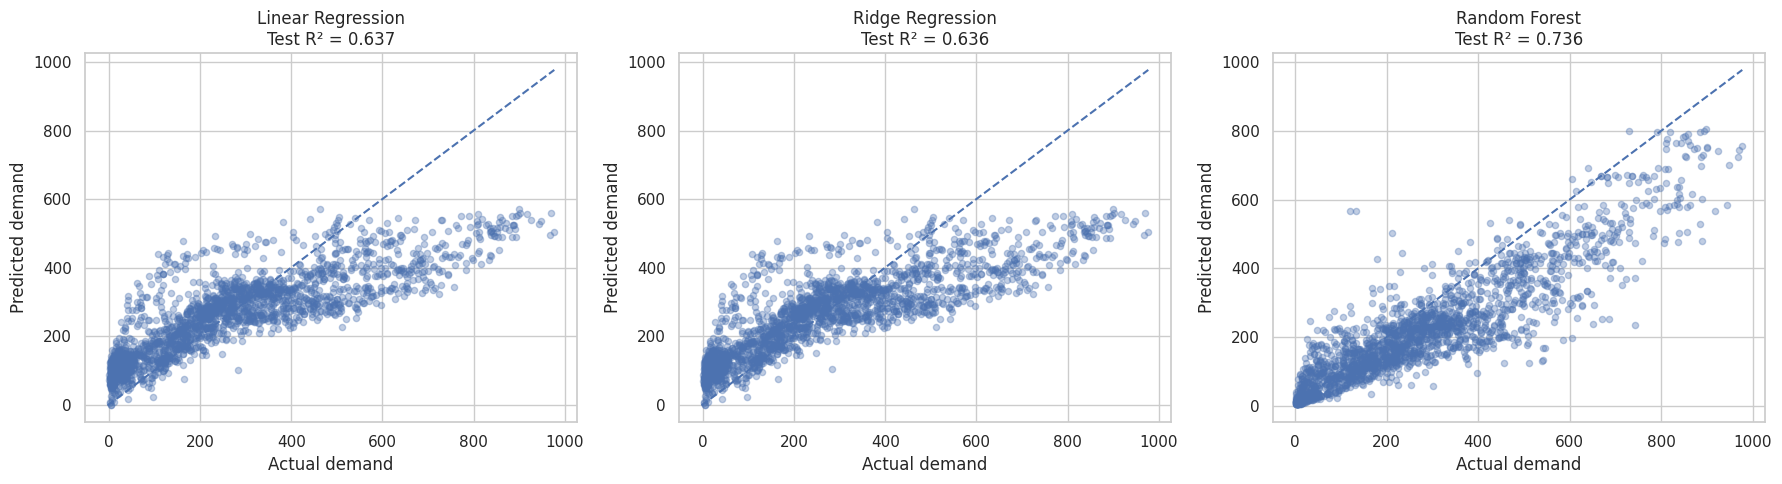

In [21]:
# Actual vs predicted plots for all fitted models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, result) in zip(axes, model_results.items()):
    preds = result["test_pred"]
    ax.scatter(y_test, preds, alpha=0.35, s=20)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax.set_title(f"{name}\nTest R² = {result['test_r2']:.3f}")
    ax.set_xlabel("Actual demand")
    ax.set_ylabel("Predicted demand")
plt.tight_layout()
plt.show()

Durbin-Watson statistic: 0.3991
Ljung-Box autocorrelation test


,lb_stat,lb_pvalue
1,"1,160.249",0.000
6,"2,041.354",0.000
12,"2,428.308",0.000
24,"3,844.796",0.000


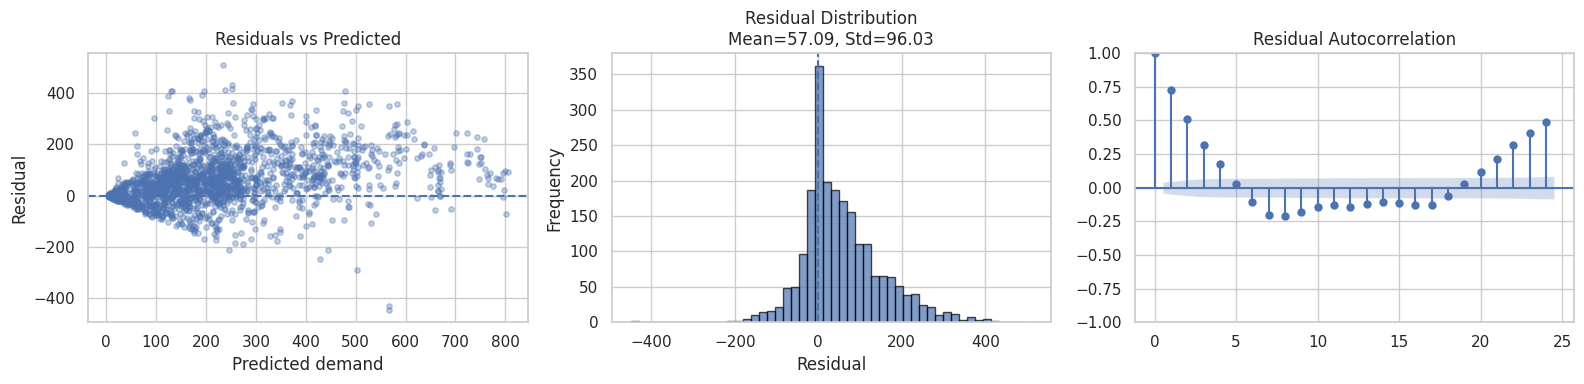


Residual autocorrelation indicates remaining time-series structure. 
 -> Future improvements could add lagged demand, rolling averages, event calendars, or location-level features.


In [22]:
# Residual diagnostics for the best model
best_test_pred = model_results[best_model_name]["test_pred"]
residuals = y_test.values - best_test_pred

dw_stat = durbin_watson(residuals)
lb_result = acorr_ljungbox(residuals, lags=[1, 6, 12, 24], return_df=True)

print(f"Durbin-Watson statistic: {dw_stat:.4f}")
print("Ljung-Box autocorrelation test")
display(lb_result)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(best_test_pred, residuals, alpha=0.35, s=15)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted demand")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[1].axvline(0, linestyle="--")
axes[1].set_title(f"Residual Distribution\nMean={np.mean(residuals):.2f}, Std={np.std(residuals):.2f}")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plot_acf(residuals, lags=24, ax=axes[2], alpha=0.05)
axes[2].set_title("Residual Autocorrelation")

plt.tight_layout()
plt.show()

print(
    "\nResidual autocorrelation indicates remaining time-series structure. "
    "\n -> Future improvements could add lagged demand, rolling averages, event calendars, or location-level features."
)

In [23]:
# Time-series cross-validation for stability -- Supplementary diagnostic only
cv = TimeSeriesSplit(n_splits=5)
cv_rows = []

for name, model in models.items():
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        val_pred = model.predict(X_val)
        fold_scores.append(r2_score(y_val, val_pred))
    cv_rows.append({
        "model": name,
        "mean_cv_r2": np.mean(fold_scores),
        "std_cv_r2": np.std(fold_scores),
        "fold_r2_scores": [round(score, 4) for score in fold_scores],
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("mean_cv_r2", ascending=False)
display(cv_results_df)

,model,mean_cv_r2,std_cv_r2,fold_r2_scores
2,Random Forest,0.551,0.181,"[0.2705, 0.5394, 0.4544, 0.7746, 0.7137]"
1,Ridge Regression,0.497,0.118,"[0.3708, 0.3535, 0.5162, 0.6003, 0.6444]"
0,Linear Regression,0.497,0.120,"[0.373, 0.3458, 0.5198, 0.6011, 0.645]"


Top transformed features


,feature,importance,original_feature
2,num__temp,0.213,temp
3,num__humidity,0.158,humidity
1,num__workingday,0.096,workingday
27,cat__hour_17,0.092,hour
28,cat__hour_18,0.081,hour
5,num__year,0.067,year
18,cat__hour_8,0.062,hour
29,cat__hour_19,0.034,hour
17,cat__hour_7,0.016,hour
11,cat__hour_1,0.014,hour



Aggregated importance by original variable


,original_feature,importance
1,hour,0.413
5,temp,0.213
2,humidity,0.158
9,workingday,0.096
10,year,0.067
3,month,0.013
7,weekday,0.012
8,windspeed,0.012
4,season,0.010
6,weather,0.006


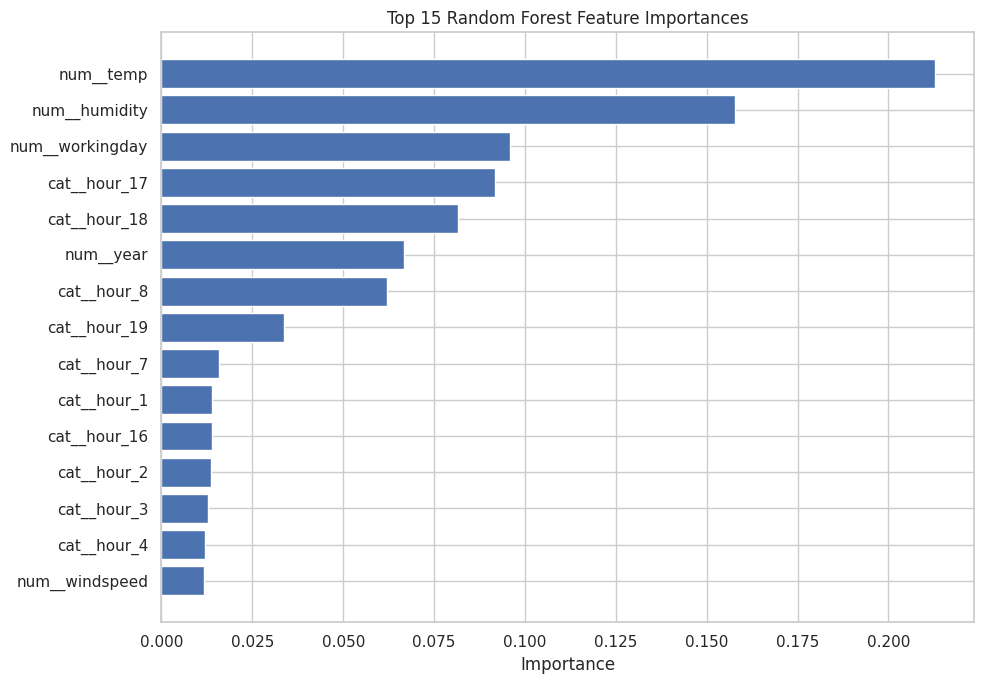

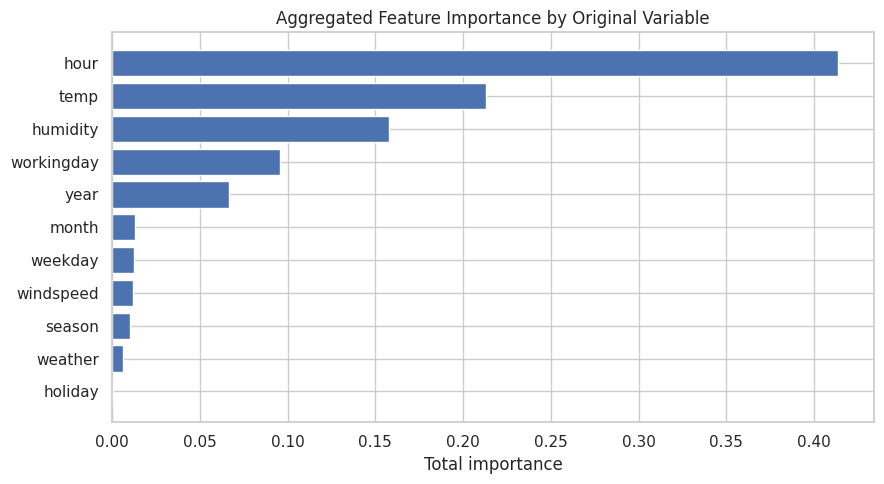

In [24]:
# Random Forest feature importance, both dummy-level and original-variable level
rf_model = model_results["Random Forest"]["model"]
preprocessor = rf_model.named_steps["preprocess"]
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

def original_feature_name(transformed_name: str) -> str:
    # Examples: num__temp -> temp, cat__hour_17 -> hour
    name = transformed_name.split("__", 1)[1]
    for prefix in ["season_", "weather_", "hour_", "weekday_", "month_"]:
        if name.startswith(prefix):
            return prefix[:-1]
    return name

feature_importance_df["original_feature"] = feature_importance_df["feature"].map(original_feature_name)
aggregated_importance_df = (
    feature_importance_df.groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("Top transformed features")
display(feature_importance_df.head(15))

print("\nAggregated importance by original variable")
display(aggregated_importance_df)

fig, ax = plt.subplots(figsize=(10, 7))
top_features = feature_importance_df.head(15).iloc[::-1]
ax.barh(top_features["feature"], top_features["importance"])
ax.set_title("Top 15 Random Forest Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
agg_plot = aggregated_importance_df.iloc[::-1]
ax.barh(agg_plot["original_feature"], agg_plot["importance"])
ax.set_title("Aggregated Feature Importance by Original Variable")
ax.set_xlabel("Total importance")
plt.tight_layout()
plt.show()

### Predictive Modeling Findings

#### Modeling Setup

* The predictive modeling section was designed to estimate total bike demand, represented by the target variable `count`.

* The variables `casual` and `registered` were excluded because they directly add up to `count`. Including them would create target leakage and make the model unrealistically accurate.

* The variable `atemp` was excluded because it is nearly collinear with `temp`. Keeping both would add redundant temperature information.

* A chronological 80/20 train-test split was used instead of a random split.

* This is appropriate because the dataset is time-based, and the model should be evaluated on future observations rather than randomly mixed past and future observations.

---

#### Model Performance

* Three models were compared:

  * Linear Regression
  * Ridge Regression
  * Random Forest

* The Random Forest model performed best on the chronological test set.

  * Test R²: **0.736**
  * Test RMSE: **111.72**
  * Test MAE: **78.37**

* Linear Regression and Ridge Regression performed similarly.

  * Linear Regression test R²: **0.637**
  * Ridge Regression test R²: **0.636**

* Ridge Regression did not materially improve over Linear Regression, suggesting that regularization was not the main limitation of the linear model.

* The stronger performance of Random Forest suggests that bike demand contains nonlinear relationships and interaction effects that simple linear models do not fully capture.

---

#### Comparison with Operational Baselines

* Simple operational baselines were included to test whether the machine learning model adds value beyond basic business rules.

* These baselines are useful because a model should not only beat other machine learning models; it should also beat simple rules that a business could easily use.

* Three baselines were tested:

  * Global Mean
  * Hour Mean
  * Hour × Weekday Mean

* The strongest baseline was the `Hour × Weekday Mean` baseline.

  * Test R²: **0.596**
  * Test RMSE: **138.22**
  * Test MAE: **94.80**

* Random Forest clearly outperformed this strongest baseline.

  * Random Forest test R²: **0.736**
  * Hour × Weekday baseline test R²: **0.596**
  * R² lift: **0.1399**
  * Relative improvement: **23.5%**

* In RMSE terms, Random Forest reduced error from **138.22** to **111.72**.

* This shows that the Random Forest is not merely learning obvious hourly and weekly demand patterns. It is adding predictive value from variables such as temperature, humidity, working day, year, and other interactions.

---

#### Metric Interpretation

* R² is useful for comparing overall model fit, but it should not be the only metric used for this time-based demand problem.

* RMSE and MAE are more directly interpretable because they are measured in the original unit: bike rental count.

* RMSE is especially useful because it penalizes large errors more heavily. This matters in demand prediction because large misses during peak-demand periods can be operationally costly.

* MAE is also useful because it shows the average absolute prediction error in a straightforward way.

* The Random Forest had:

  * RMSE: **111.72**
  * MAE: **78.37**

* This means the model’s average absolute error is about **78 rentals**, while larger errors increase the RMSE to about **112 rentals**.

---

#### Time-Series Cross-Validation

* Random K-fold cross-validation would not be appropriate for this dataset because it would mix past and future observations, creating future-data leakage.

* However, time-series cross-validation is valid when it respects chronological order.

* The `TimeSeriesSplit` approach is appropriate because each fold trains on earlier data and validates on a later period.

* The cross-validation results showed that Random Forest had the highest average CV R².

  * Mean CV R²: **0.551**
  * Standard deviation: **0.181**
  * Fold scores: **[0.2705, 0.5394, 0.4544, 0.7746, 0.7137]**

* The Random Forest performed best on average, but its fold scores were also more variable than the linear models.

* This suggests that the model is powerful, but its performance depends on which time period it is trained and validated on.

* A better workflow would be to run time-series cross-validation only on the training set, and keep the final chronological test set untouched for final model evaluation.

---

#### Residual Diagnostics

* Residual diagnostics showed strong remaining time-series structure.

  * Durbin-Watson statistic: **0.3991**
  * Ljung-Box p-values: **0.000** across lags 1, 6, 12, and 24

* A Durbin-Watson statistic far below 2 indicates strong positive autocorrelation in residuals.

* The Ljung-Box test confirms that the residuals are significantly autocorrelated across multiple lags.

* This means the model’s errors are not fully random.

* In practical terms, when the model overpredicts or underpredicts demand, nearby time periods tend to show related errors.

* This indicates that the model is still missing some sequential demand patterns.

---

#### Feature Importance

* The most important feature group was `hour`.

  * Aggregated importance: **0.413**

* This confirms that time of day is the dominant driver of bike demand.

* The next most important predictors were:

  * `temp`: **0.213**
  * `humidity`: **0.158**
  * `workingday`: **0.096**
  * `year`: **0.067**

* Temperature and humidity are strong predictors, which confirms that bike rental demand is highly weather-sensitive.

* The importance of `workingday` does not contradict the earlier Mann-Whitney test result.

* The Mann-Whitney test showed that the overall demand distribution between working and non-working days was not meaningfully different.

* However, the Random Forest can capture interaction effects. Working days and non-working days may have similar overall demand but very different hourly demand patterns.

* `holiday` had almost zero importance, which is consistent with the earlier statistical test showing negligible difference between holiday and non-holiday demand.

* `weather`, `season`, and `month` had lower importance after including more direct predictors such as `temp`, `humidity`, `hour`, and `year`.

---

#### Overall Conclusion

* The Random Forest was the best-performing model among the models tested.

* It outperformed both linear models and simple operational baselines.

* The model captures important nonlinear relationships between demand, time, weather, and calendar variables.

* The operational baseline comparison confirms that the Random Forest adds real predictive value beyond simple hourly or weekday-hour averages.

* However, the residual diagnostics show that the model has not fully captured the time-series structure in the data.

* Future improvements should include lag-based and rolling-window features, such as:

  * Previous-hour demand
  * Same-hour previous-day demand
  * Rolling 3-hour average demand
  * Rolling 24-hour average demand
  * Same weekday-hour historical average
  * Event or holiday calendar indicators
  * Location-level features, if available

* Overall, the current model is a strong tabular prediction model, but it can be improved further by adding features that explicitly capture sequential demand behavior.


## 9. Insights and Business Recommendations

---

### Variables which are significant in predicting demand

The analysis shows that bike demand is driven mainly by **time-based patterns**, followed by **seasonality**, **weather conditions**, and **long-term growth trends**.

#### Most Important Demand Drivers:

| Rank | Variable     | Evidence                             | Business Interpretation                                                                         |
| ---: | ------------ | ------------------------------------ | ----------------------------------------------------------------------------------------------- |
|    1 | `hour`       | Highest feature importance           | Demand varies sharply across the day, with very low overnight demand and strong commute peaks.  |
|    2 | `season`     | Kruskal-Wallis H = 699.88, p < 0.001 | Season has a meaningful impact; Spring has the lowest demand while Fall has the highest demand. |
|    3 | `weather`    | Kruskal-Wallis H = 204.96, p < 0.001 | Clear weather produces substantially higher demand than rain/snow conditions.                   |
|    4 | `temp`       | r ≈ +0.39                            | Warmer temperatures are associated with higher bike demand.                                     |
|    5 | `year`       | High model importance                | Demand increased strongly from 2011 to 2012, suggesting user adoption and business growth.      |
|    6 | `humidity`   | r ≈ -0.32                            | Higher humidity is associated with lower bike demand.                                           |
|    7 | `workingday` | Mann-Whitney p = 0.967 overall       | Not significant as a standalone binary variable, but highly useful when combined with `hour`.   |
|    8 | `holiday`    | Mann-Whitney p = 0.865 overall       | Not statistically significant in the overall binary test.                                       |

#### Important Interaction: `hour × workingday`

Although `workingday` is not significant by itself, it becomes operationally important when combined with `hour`.

* On **working days**, demand shows a commuter pattern with peaks around **8 AM** and **5-6 PM**.
* On **non-working days**, demand follows a broader **midday leisure pattern**.
* This means `workingday` should not be interpreted only as a standalone variable; its value is mainly in explaining how demand changes across the day.

#### Variables Excluded from Modeling

* `casual` and `registered` were excluded because they are direct components of the target variable:
  `count = casual + registered`
  Including them would create **target leakage**.
* `atemp` was excluded because it is almost perfectly correlated with `temp`, creating **multicollinearity**.

---

### How well do these variables explain demand?

The best-performing model is the **Random Forest**, evaluated using a chronological train-test split to avoid future-data leakage.

| Metric    |     Random Forest | Linear Regression |  Ridge Regression |
| --------- | ----------------: | ----------------: | ----------------: |
| Train R²  |            0.9192 |            0.6946 |            0.6946 |
| Test R²   |            0.7365 |            0.6372 |            0.6365 |
| Test RMSE | 111.72 bikes/hour | 131.06 bikes/hour | 131.18 bikes/hour |
| Test MAE  |  78.37 bikes/hour |  98.17 bikes/hour |  98.24 bikes/hour |

#### Model Interpretation

* The Random Forest explains about **74% of demand variance** on the chronological test set.
* This indicates that demand is **reasonably predictable** using time, weather, season, and calendar variables.
* Random Forest clearly outperforms linear models because it captures **non-linear effects** and **interactions**, especially between variables like `hour`, `workingday`, `season`, and `weather`.
* The model also improves over simple operational baselines such as the global mean, hour-only mean, and hour-by-weekday mean.
* Time-series cross-validation performance is lower and more variable, which is expected because different time periods have different seasonal patterns and growth trends.

#### Remaining Unexplained Variation

The remaining unexplained variation may be due to factors not available in the dataset, such as:

* Special events
* Local station-level availability
* Promotions or marketing campaigns
* System outages
* Real-time weather changes
* Holidays or events not fully captured by the binary holiday variable
* Random short-term demand fluctuations

---

### Key Business Insights

#### Demand Patterns

* Demand is strongly time-dependent, with the highest demand during commute periods.
* Evening demand is especially important, with the **5-6 PM peak** being one of the strongest demand windows.
* Registered users account for the majority of demand, indicating that the service is heavily used for recurring or commuter-style trips.
* Demand increased sharply from 2011 to 2012, suggesting strong year-over-year adoption growth.

#### Environmental Impact

* Demand is highest in warmer temperatures.
* Higher humidity is associated with lower demand.
* Rain/snow conditions reduce demand substantially compared with clear weather.
* Seasonality matters: Spring has the lowest demand, while Fall has the highest demand.

#### Predictability

* The final model explains approximately **74% of demand variance**, which is strong enough for practical operational planning.
* However, predictions should still include uncertainty buffers because short-term demand can be affected by external factors not present in the dataset.

---

### Recommendations

#### 1. Capacity Planning

* Pre-position bikes before the **8 AM** and **5-6 PM** commute peaks.
* Allocate the highest operational capacity during evening peak hours.
* Increase fleet availability during high-demand seasons, especially Summer and Fall.
* Reduce deployment expectations during rain/snow conditions.

#### 2. Pricing Strategy

* Consider peak-hour pricing during high-demand windows such as **8-9 AM** and **5-7 PM**.
* Use weather-based discounts during low-demand weather conditions to maintain utilization.
* Run Spring promotions to increase usage during the lowest-demand season.

#### 3. User Growth Strategy

* Prioritize registered-user retention because registered riders make up the majority of demand.
* Target commuters through corporate partnerships, office-area campaigns, and subscription plans.
* Convert casual riders into registered users using membership offers, loyalty benefits, or ride bundles.

#### 4. Operations and Rebalancing

* Rebalance bikes before commute peaks based on expected residential-to-commercial and commercial-to-residential movement.
* Use the demand forecasting model for daily and hourly planning.
* Add buffer capacity during high-demand hours because prediction errors can still be meaningful in absolute terms.

#### 5. Maintenance Scheduling

* Schedule regular maintenance during **2-5 AM**, when demand is lowest.
* Plan major maintenance or fleet overhauls during Spring, the lowest-demand season.

#### 6. Model Improvement

Future versions of the model could be improved by adding:

* Lagged demand features
* Rolling average demand
* Real-time weather forecasts
* Station/location-level information
* Special event indicators
* Promotion and campaign data
* Outage or bike-availability data
* Public transit disruption indicators
